# Data Preprocessing - BRFSS 2015 Diabetes Dataset

This notebook handles data loading, exploration, and preprocessing for the diabetes dataset.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('data/BRFSS2015.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (70692, 22)

Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

First few rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 3. Data Exploration

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\n\nDataset info:")
df.info()

Missing values:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             706

Target distribution (Diabetes_binary):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

Percentage:
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


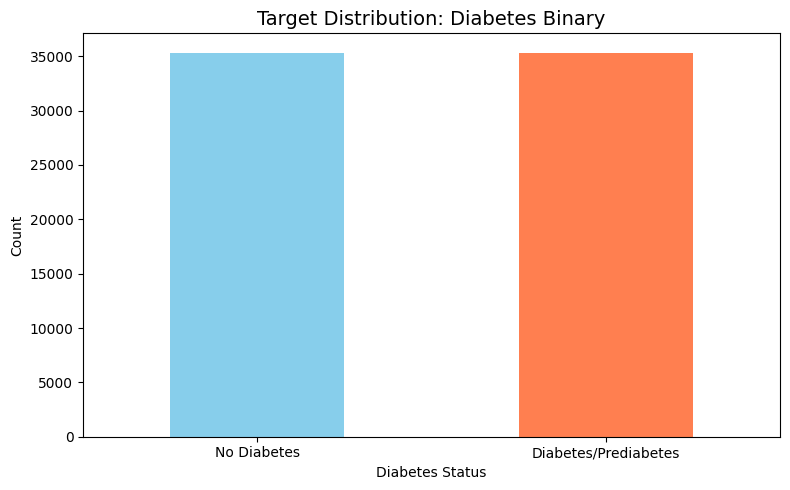

In [4]:
# Target distribution
print("Target distribution (Diabetes_binary):")
print(df['Diabetes_binary'].value_counts())
print(f"\nPercentage:")
print(df['Diabetes_binary'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(8, 5))
df['Diabetes_binary'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Target Distribution: Diabetes Binary', fontsize=14)
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes/Prediabetes'], rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Statistical summary
print("Statistical summary:")
df.describe()

Statistical summary:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## 4. Feature Engineering & Preprocessing

In [6]:
# Separate features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (70692, 21)
Target shape: (70692,)

Feature columns (21):
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## 5. Train-Test Split

In [7]:
# Split the data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 56553 samples
Test set size: 14139 samples

Training set target distribution:
Diabetes_binary
1.0    28277
0.0    28276
Name: count, dtype: int64

Test set target distribution:
Diabetes_binary
0.0    7070
1.0    7069
Name: count, dtype: int64


## 6. Feature Scaling (MinMaxScaler)

**Critical for Differential Privacy**: MinMaxScaler bounds all features to [-1, 1], providing:
1. **Guaranteed theoretical bounds** — no privacy leakage from data-dependent bound computation
2. **Known max L₂ norm** — for d features, max ||x||₂ = √d
3. **Straightforward sensitivity calibration** — noise scale directly computable from bounds

In [8]:
# Initialize MinMaxScaler with range [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

# Verify scaling bounds
print(f"\nScaled training data statistics:")
print(f"Min: {X_train_scaled.min(axis=0)}")
print(f"Max: {X_train_scaled.max(axis=0)}")
print(f"\nAll features bounded to [-1, 1]: {np.allclose(X_train_scaled.min(), -1.0) and np.allclose(X_train_scaled.max(), 1.0)}")
print(f"Max L2 norm (theoretical): sqrt({n_features}) = {np.sqrt(n_features):.4f}")
print(f"Max L2 norm (actual train): {np.max(np.linalg.norm(X_train_scaled, axis=1)):.4f}")

Scaled training data shape: (56553, 21)
Scaled test data shape: (14139, 21)

Scaled training data statistics:
Min: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1.]
Max: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

All features bounded to [-1, 1]: True
Max L2 norm (theoretical): sqrt(21) = 4.5826
Max L2 norm (actual train): 4.5725


## 7. Define Theoretical Bounds for DP Models

With MinMaxScaler(feature_range=(-1, 1)), bounds are **data-independent** and derived purely from the scaler's output guarantee. No privacy leakage — these are mathematical properties of the transformation, not statistics of the data.

In [9]:
# Theoretical bounds from MinMaxScaler: every feature is in [-1, 1]
# These bounds are data-independent — they follow from the scaler definition
n_features = X_train_scaled.shape[1]
lower_bound = np.full(n_features, -1.0)
upper_bound = np.full(n_features, 1.0)
bounds = (lower_bound, upper_bound)

print(f"Theoretical feature bounds (data-independent):")
print(f"  Lower: [-1.0] × {n_features} features")
print(f"  Upper: [+1.0] × {n_features} features")
print(f"\nDP Sensitivity properties:")
print(f"  Max L2 norm of any sample: sqrt({n_features}) = {np.sqrt(n_features):.4f}")
print(f"  Per-feature range: 2.0 (from -1 to +1)")
print(f"\nNo privacy leakage: bounds are a mathematical property of MinMaxScaler, not data statistics.")

Theoretical feature bounds (data-independent):
  Lower: [-1.0] × 21 features
  Upper: [+1.0] × 21 features

DP Sensitivity properties:
  Max L2 norm of any sample: sqrt(21) = 4.5826
  Per-feature range: 2.0 (from -1 to +1)

No privacy leakage: bounds are a mathematical property of MinMaxScaler, not data statistics.


## 8. Save Preprocessed Data

In [10]:
# Create data directory if it doesn't exist
import os
os.makedirs('data', exist_ok=True)

# Save as pickle file
processed_data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train.values,
    'y_test': y_test.values,
    'feature_names': X.columns.tolist(),
    'bounds': bounds,
    'scaler': scaler
}

with open('data/processed_data.pkl', 'wb') as f:
    pickle.dump(processed_data, f)

print("✓ Preprocessed data saved to 'data/processed_data.pkl'")
print(f"\nSaved objects:")
print(f"  - X_train: {X_train_scaled.shape}")
print(f"  - X_test: {X_test_scaled.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"  - feature_names: {len(X.columns)} features")
print(f"  - bounds: lower and upper bounds for DP")
print(f"  - scaler: StandardScaler object")

✓ Preprocessed data saved to 'data/processed_data.pkl'

Saved objects:
  - X_train: (56553, 21)
  - X_test: (14139, 21)
  - y_train: (56553,)
  - y_test: (14139,)
  - feature_names: 21 features
  - bounds: lower and upper bounds for DP
  - scaler: StandardScaler object


## 9. Summary

In [11]:
print("="*60)
print("DATA PREPROCESSING SUMMARY")
print("="*60)
print(f"Dataset: BRFSS 2015 Diabetes Dataset")
print(f"Total samples: {df.shape[0]:,}")
print(f"Features: {X.shape[1]}")
print(f"\nTrain-Test Split (80/20):")
print(f"  Training: {X_train.shape[0]:,} samples")
print(f"  Test: {X_test.shape[0]:,} samples")
print(f"\nPreprocessing:")
print(f"  ✓ StandardScaler applied (μ=0, σ=1)")
print(f"  ✓ Feature bounds computed for DP")
print(f"  ✓ Data saved to pickle file")
print(f"\nReady for model training!")
print("="*60)

DATA PREPROCESSING SUMMARY
Dataset: BRFSS 2015 Diabetes Dataset
Total samples: 70,692
Features: 21

Train-Test Split (80/20):
  Training: 56,553 samples
  Test: 14,139 samples

Preprocessing:
  ✓ StandardScaler applied (μ=0, σ=1)
  ✓ Feature bounds computed for DP
  ✓ Data saved to pickle file

Ready for model training!
